In [1]:
# Get GPU information
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Mon Nov 11 18:38:52 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off | 00000000:00:04.0 Off |                    0 |
| N/A   30C    P0              44W / 400W |      2MiB / 40960MiB |      0%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

In [2]:
# Get available RAM for the GPU
from psutil import virtual_memory
ram_gb = virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

Your runtime has 89.6 gigabytes of available RAM

You are using a high-RAM runtime!


In [3]:
!pip install ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.8/883.8 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.9/80.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.3 MB/s eta 0:00:00
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10


In [4]:
import os
import json
from roboflow import Roboflow
from IPython.display import Image

In [5]:
def load_dataset(path):
    """
    Load dataset from Roboflow

    Args:
        path (str): path to json file with api key

    returns:
        dataset: downloaded dataset
    """

    # Check if roboflow api credentials file exists
    if not os.path.exists(path):
      print("Roboflow api credentials file not found")
      return

    # Load Roboflow API key
    roboflow_api = json.load(open(path))
    rf = Roboflow(api_key=roboflow_api["api_key"])
    # Download dataset
    project = rf.workspace("roboflow-jvuqo").project("football-field-detection-f07vi")
    version = project.version(12)
    dataset = version.download("yolov8")

    return dataset

In [6]:
dataset = load_dataset("Roboflow.json")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to football-field-detection-12 in yolov8:: 100%|██████████| 564/564 [00:00<00:00, 2717.01it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [7]:
# Update yaml file structure
!sed -i 's|\(train: \).*|\1../train/images|' {dataset.location}/data.yaml
!sed -i 's|\(val: \).*|\1../valid/images|' {dataset.location}/data.yaml

In [8]:
HOME = os.getcwd()
print(HOME)

/content


In [12]:
%cd {HOME}

!yolo task=pose mode=train model=yolo11x-pose.pt data={dataset.location}/data.yaml batch=32 epochs=300 imgsz=640 mosaic=0.0 plots=True

/content
Ultralytics 8.3.29 🚀 Python-3.10.12 torch-2.5.0+cu121 CUDA:0 (NVIDIA A100-SXM4-40GB, 40514MiB)
engine/trainer: task=pose, mode=train, model=yolo11x-pose.pt, data=/content/football-field-detection-12/data.yaml, epochs=300, time=None, patience=100, batch=32, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train4, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=Fals

In [18]:
!ls {HOME}/runs/pose/train4/

args.yaml					     labels.jpg        train_batch2030.jpg
BoxF1_curve.png					     PoseF1_curve.png  train_batch2031.jpg
BoxP_curve.png					     PoseP_curve.png   train_batch2032.jpg
BoxPR_curve.png					     PosePR_curve.png  train_batch2.jpg
BoxR_curve.png					     PoseR_curve.png   val_batch0_labels.jpg
confusion_matrix_normalized.png			     results.csv       val_batch0_pred.jpg
confusion_matrix.png				     results.png       weights
events.out.tfevents.1731353248.3a08ac4625e2.15304.0  train_batch0.jpg
labels_correlogram.jpg				     train_batch1.jpg


/content


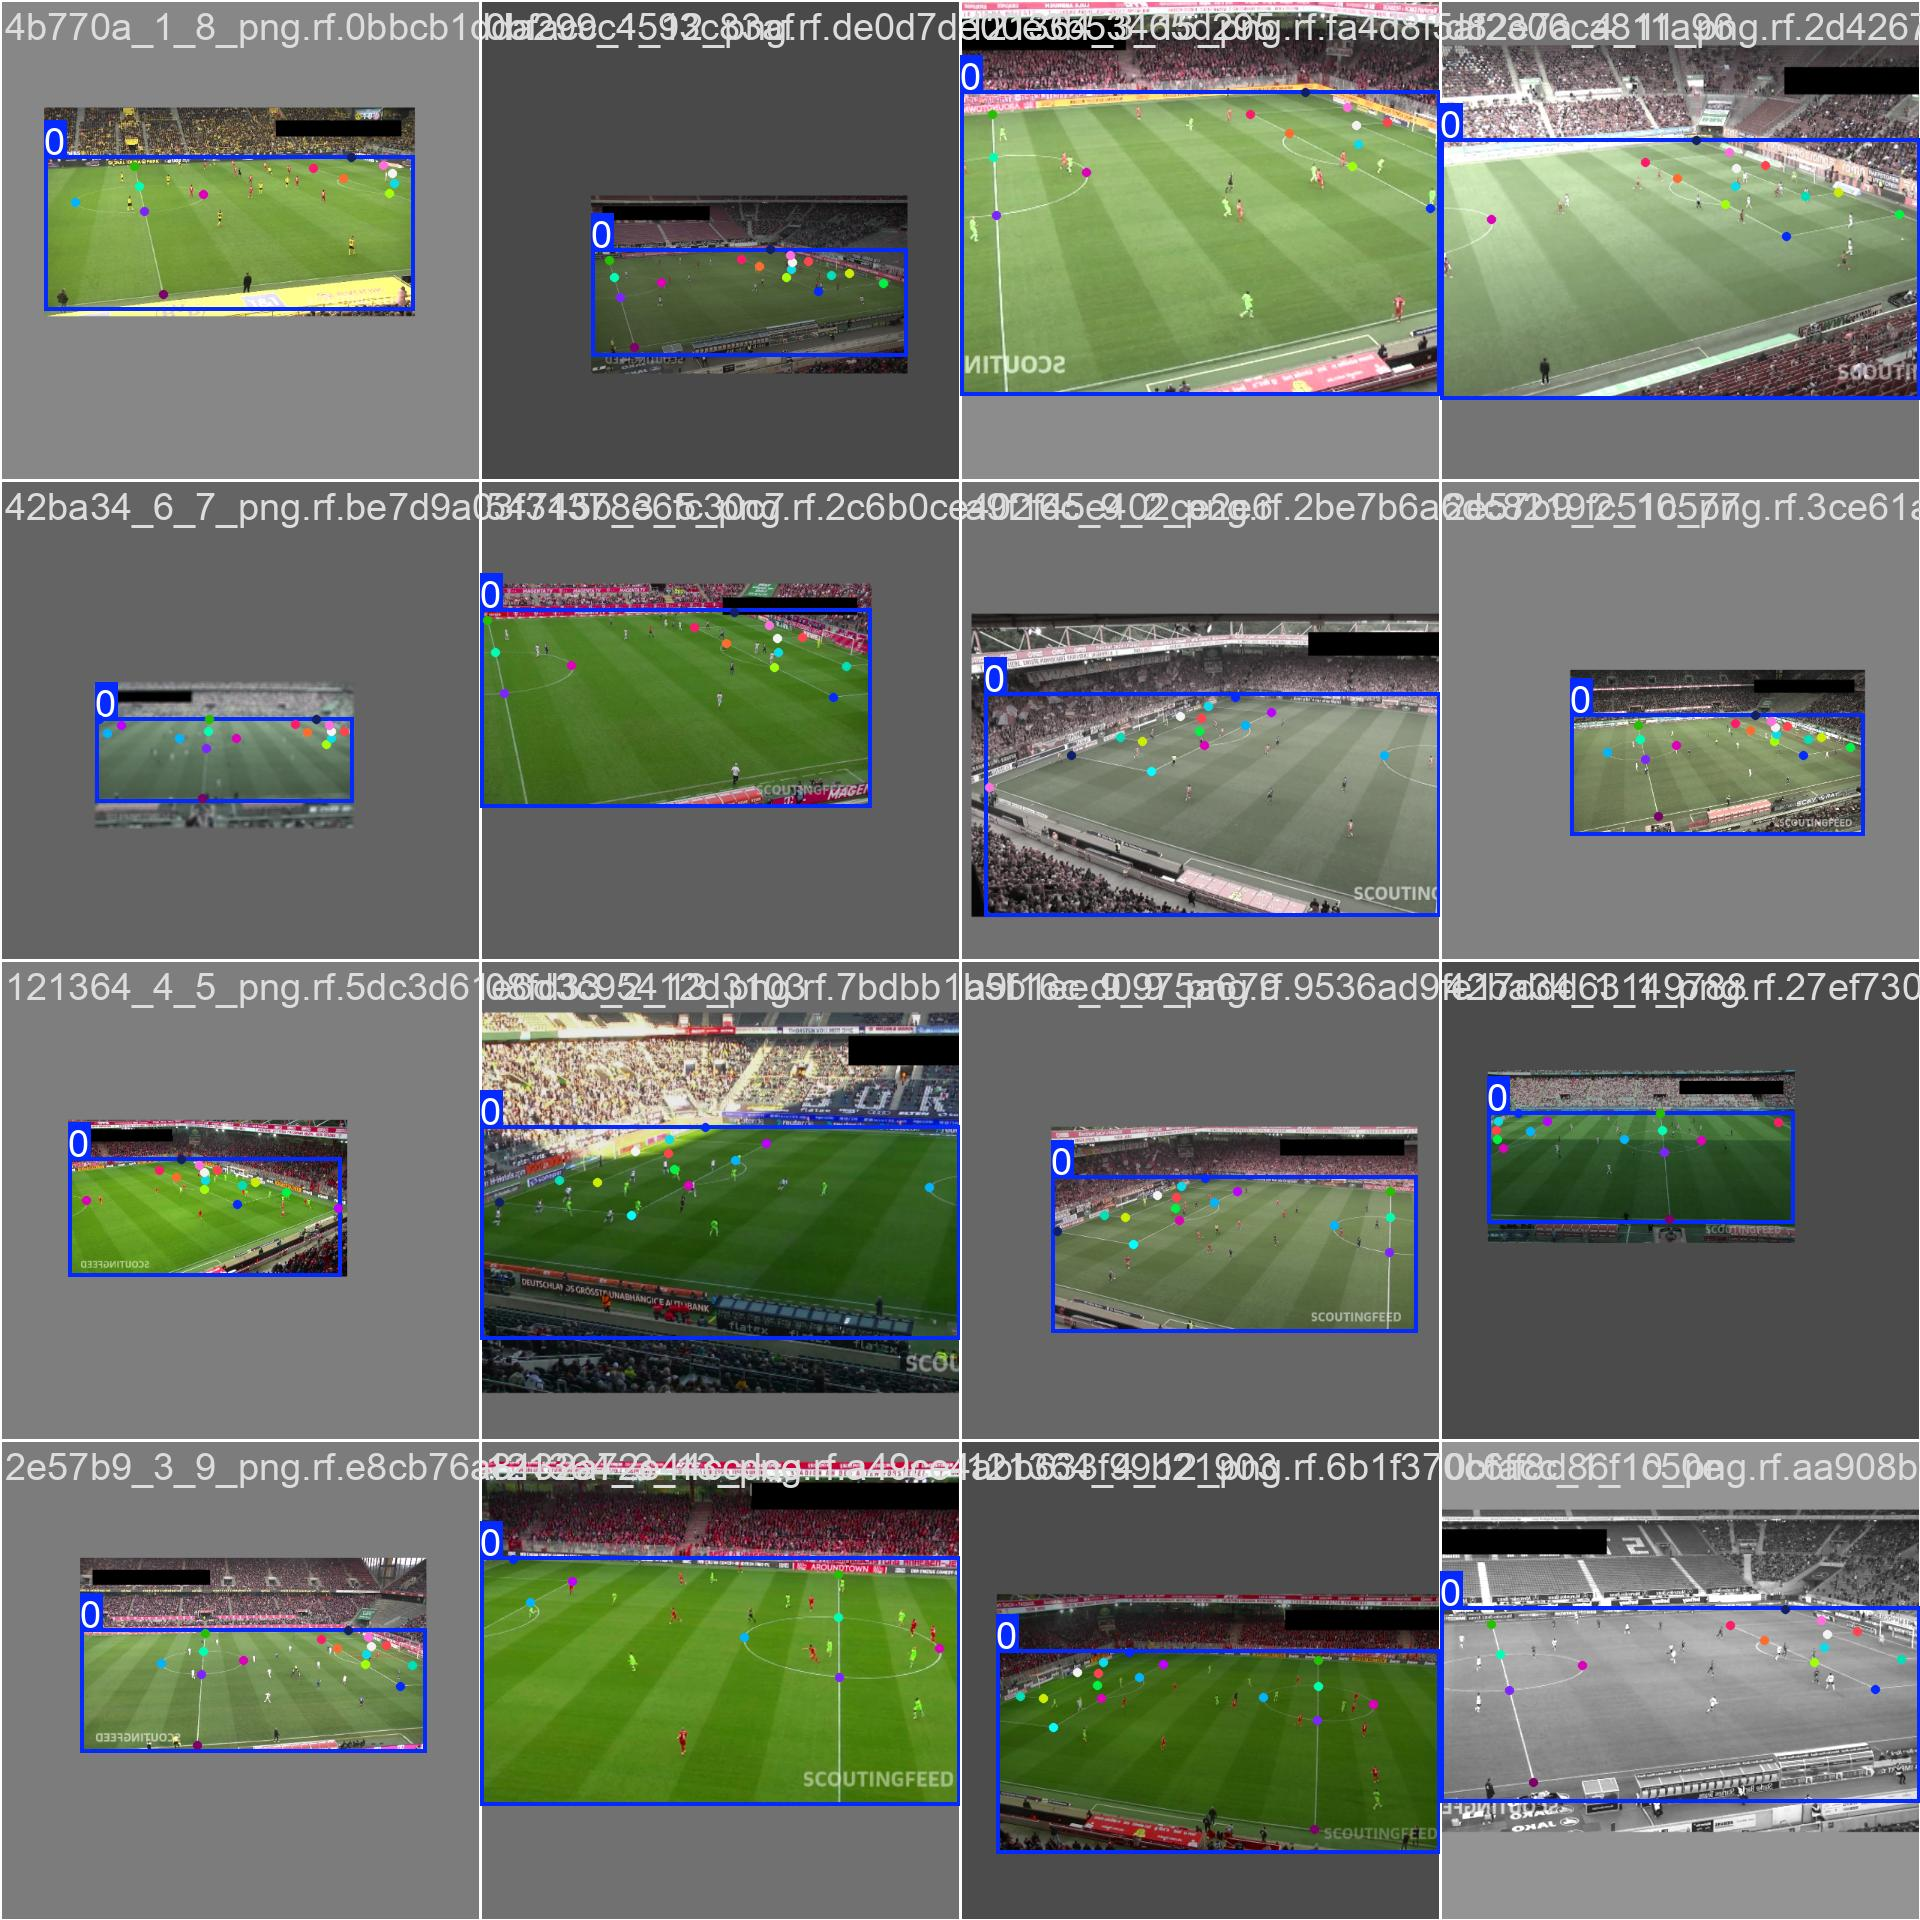

In [16]:
%cd {HOME}
Image(filename=f'{HOME}/runs/pose/train4/train_batch0.jpg', width=600)

/content


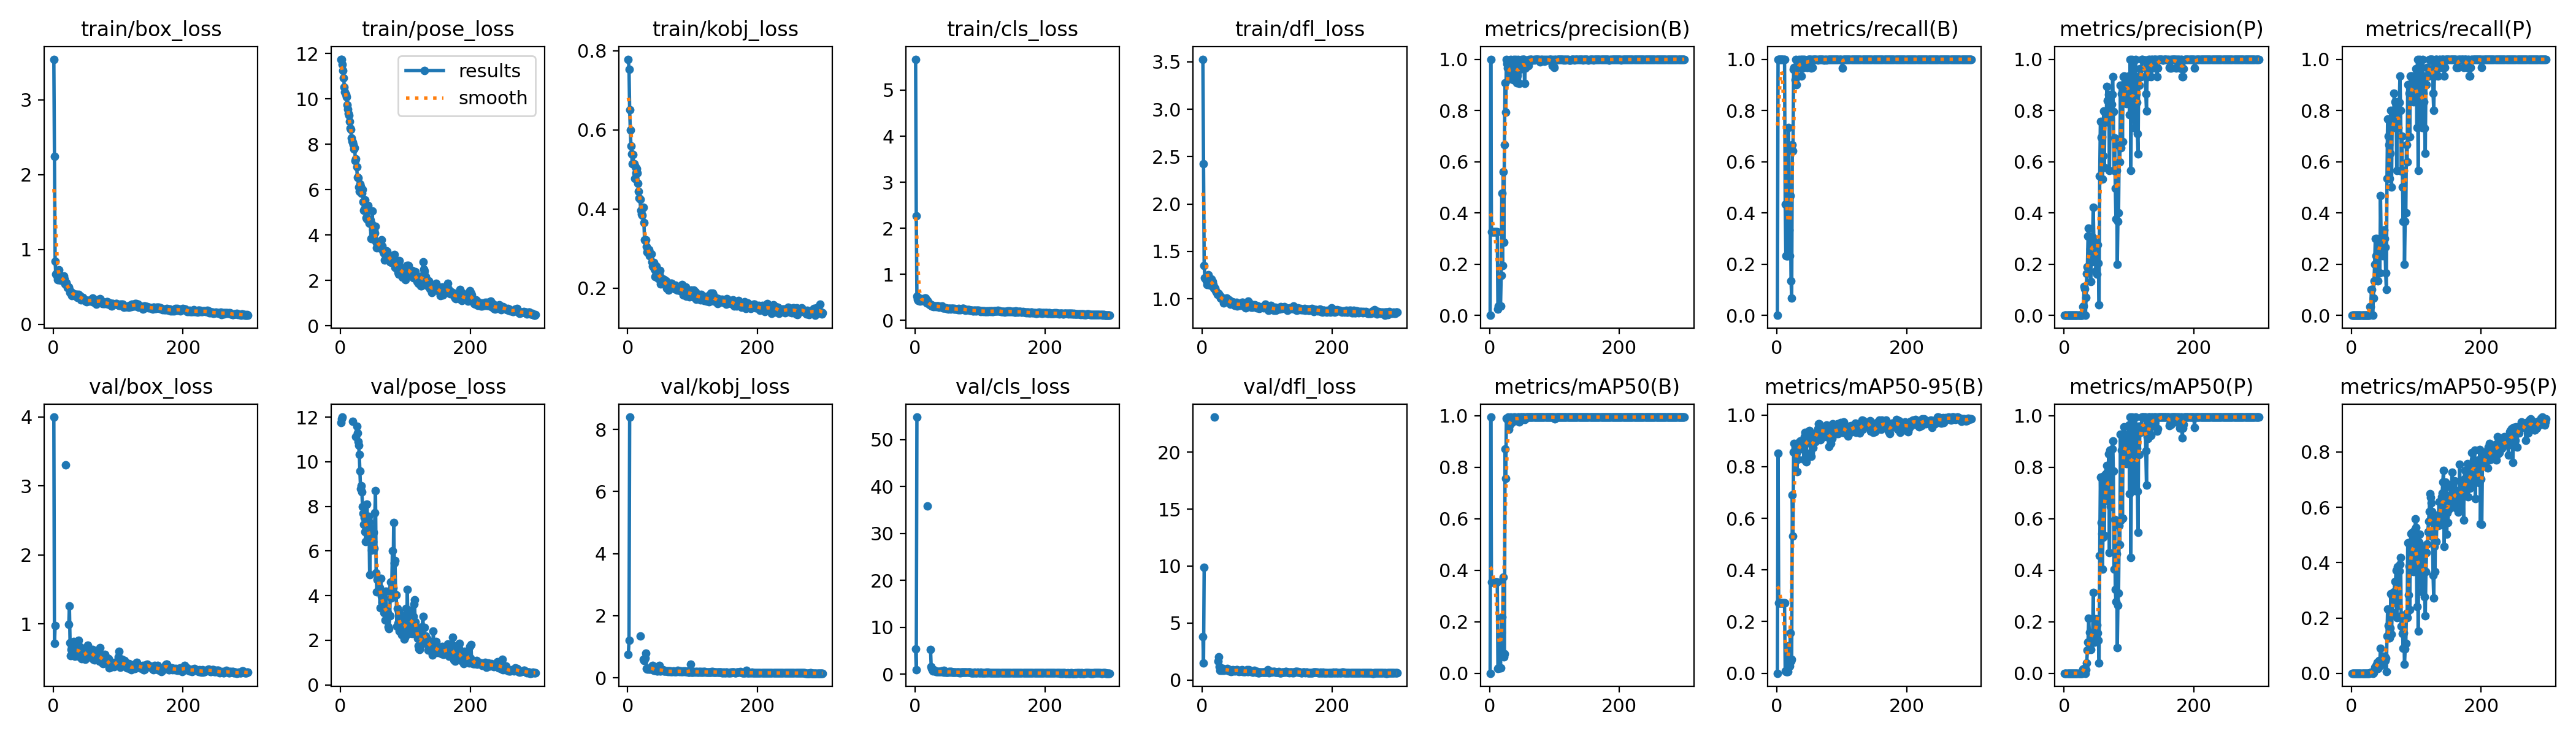

In [20]:
%cd {HOME}
Image(filename=f'{HOME}/runs/pose/train4/results.png', width=600)

In [21]:
%cd {HOME}

!yolo task=pose mode=val model={HOME}/runs/pose/train4/weights/best.pt data={dataset.location}/data.yaml

/content
Ultralytics 8.3.29 🚀 Python-3.10.12 torch-2.5.0+cu121 CUDA:0 (NVIDIA A100-SXM4-40GB, 40514MiB)
YOLO11x-pose summary (fused): 483 layers, 58,764,403 parameters, 0 gradients, 202.9 GFLOPs
val: Scanning /content/football-field-detection-12/valid/labels.cache... 30 images, 0 backgrounds, 0 corrupt: 100% 30/30 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100% 2/2 [00:01<00:00,  1.28it/s]
                   all         30         30          1          1      0.995      0.989          1          1      0.995      0.924
Speed: 1.4ms preprocess, 16.6ms inference, 0.0ms loss, 21.4ms postprocess per image
Results saved to runs/pose/val
💡 Learn more at https://docs.ultralytics.com/modes/val
